#**FIFA World Cup 2026 Champion Prediction Using Machine Learning**


## Disusun Oleh
[Dimas Ramdani, 2330511004]

[Muhamad Daffa, 2330511024]

# Deskripsi Singkat

Proyek ini bertujuan untuk membangun model Machine Learning yang dapat memprediksi peluang suatu negara menjadi juara FIFA World Cup 2026 berdasarkan data historis Piala Dunia, FIFA Ranking, dan Elo Rating.

Metodologi yang digunakan mengikuti CRISP-DM (Cross Industry Standard Process for Data Mining), yang terdiri dari Business Understanding, Data Understanding, Data Preparation, Modeling, Evaluation, dan Deployment.

# 1. Business Understanding

## Latar Belakang

FIFA World Cup merupakan kompetisi sepak bola terbesar di dunia yang mempertemukan tim nasional terbaik dari berbagai negara. Menentukan kandidat juara sebelum turnamen berlangsung menjadi tantangan karena dipengaruhi oleh berbagai faktor seperti kekuatan tim, ranking FIFA, performa pertandingan, dan pengalaman internasional.

Dengan memanfaatkan Machine Learning, data historis dapat digunakan untuk menemukan pola yang berkaitan dengan keberhasilan suatu negara menjadi juara dunia.

Model yang dibangun diharapkan mampu memberikan gambaran negara-negara yang memiliki peluang terbesar untuk menjadi juara FIFA World Cup 2026.

## Problem Statement

1. Faktor apa saja yang mempengaruhi peluang suatu negara menjadi juara Piala Dunia?
2. Apakah data historis FIFA Ranking dan Elo Rating dapat digunakan untuk memprediksi juara dunia?
3. Negara mana yang memiliki peluang terbesar menjadi juara FIFA World Cup 2026?

## Goals

1. Mengidentifikasi faktor-faktor yang berpengaruh terhadap peluang juara dunia.
2. Membangun model Machine Learning menggunakan algoritma Random Forest.
3. Menghasilkan prediksi kandidat juara FIFA World Cup 2026 berdasarkan data terbaru.

## Solution Approach

Pendekatan yang digunakan dalam proyek ini adalah supervised learning dengan algoritma Random Forest Classifier.

Random Forest dipilih karena mampu:

- Menangani hubungan non-linear antar fitur.
- Mengurangi risiko overfitting.
- Memberikan informasi feature importance.
- Memiliki performa yang baik pada dataset tabular.

In [63]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings('ignore')

# 2. Data Understanding

In [67]:
from google.colab import files

uploaded = files.upload()

Saving WC.csv to WC.csv
Saving elo_ratings_wc2026.csv to elo_ratings_wc2026.csv
Saving fifa_ranking_2026-06-08.csv to fifa_ranking_2026-06-08.csv


## Dataset

Proyek ini menggunakan tiga dataset utama:

### 1. WC.csv
Berisi data historis FIFA World Cup termasuk negara juara setiap edisi.

### 2. fifa_ranking_2026-06-08.csv
Berisi ranking FIFA terbaru setiap negara.

### 3. elo_ratings_wc2026.csv
Berisi Elo Rating dan statistik performa tim nasional.

Ketiga dataset digabungkan untuk membentuk dataset yang digunakan dalam proses pemodelan.

In [69]:
wc = pd.read_csv('WC.csv')

ranking = pd.read_csv('fifa_ranking_2026-06-08.csv')

elo = pd.read_csv('elo_ratings_wc2026.csv')

In [72]:
wc.head()
ranking.head()
elo.head()

,year,snapshot_date,country,rank,country_code,rating,rank_max,rating_max,rank_avg,rating_avg,...,matches_home,matches_away,matches_neutral,wins,losses,draws,goals_for,goals_against,confederation,is_host
0,1901,1901-12-31,England,1,EN,2013,1,2079,2,1989,...,38,35,0,46,16,11,262,102,UEFA,0
1,1901,1901-12-31,Scotland,2,SQ,1973,1,2104,1,2018,...,37,37,0,53,9,12,277,101,UEFA,0
2,1902,1902-12-31,Argentina,1,AR,2021,1,2021,1,2021,...,0,1,0,1,0,0,6,0,CONMEBOL,0
3,1902,1902-12-31,England,2,EN,1995,1,2079,2,1989,...,39,38,0,47,16,14,266,105,UEFA,0
4,1902,1902-12-31,Scotland,3,SQ,1983,1,2104,1,2017,...,39,40,0,56,9,14,293,106,UEFA,0


## Struktur Dataset

Tahap ini dilakukan untuk memahami jumlah data, tipe data, dan struktur setiap dataset.

In [73]:
wc.info()
ranking.info()
elo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Year            20 non-null     int64 
 1   Country         20 non-null     object
 2   Winner          20 non-null     object
 3   Runners-Up      20 non-null     object
 4   Third           20 non-null     object
 5   Fourth          20 non-null     object
 6   GoalsScored     20 non-null     int64 
 7   QualifiedTeams  20 non-null     int64 
 8   MatchesPlayed   20 non-null     int64 
 9   Attendance      20 non-null     object
dtypes: int64(4), object(6)
memory usage: 1.7+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211 entries, 0 to 210
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   team             211 non-null    object 
 1   team_code        211 non-null    object 
 2   association      211 non-n

In [74]:
print("WC :", wc.shape)

print("Ranking :", ranking.shape)

print("ELO :", elo.shape)

WC : (20, 10)
Ranking : (211, 8)
ELO : (4683, 23)


## Missing Value Analysis

Pemeriksaan missing value dilakukan untuk memastikan kualitas data sebelum digunakan dalam proses pemodelan.

In [75]:
wc.isnull().sum()
ranking.isnull().sum()
elo.isnull().sum()

,0
year,0
snapshot_date,0
country,0
rank,0
country_code,0
rating,0
rank_max,0
rating_max,0
rank_avg,0
rating_avg,0


## Statistik Deskriptif

Statistik deskriptif digunakan untuk melihat karakteristik numerik dari dataset Elo Rating.

In [76]:
elo.describe()

,year,rank,rating,rank_max,rating_max,rank_avg,rating_avg,rank_min,rating_min,matches_total,matches_home,matches_away,matches_neutral,wins,losses,draws,goals_for,goals_against,is_host
count,4683.000000,4683.000000,4683.000000,4683.000000,4683.000000,4683.000000,4683.000000,4683.000000,4683.000000,4683.000000,4683.000000,4683.000000,4683.000000,4683.000000,4683.000000,4683.000000,4683.000000,4683.000000,4683.000000
mean,1975.612428,38.580397,1692.405296,18.203288,1828.045697,36.375400,1660.898142,60.699979,1516.704463,304.515482,123.752936,120.279095,60.483451,139.371770,98.065343,67.078369,555.347000,428.007474,0.068546
std,32.255221,33.021081,210.380644,22.281645,223.437088,30.728601,205.305537,39.790522,208.226429,270.665854,114.171468,110.397608,74.783374,137.463559,81.378835,64.168127,518.491329,343.187644,0.252707
min,1901.000000,1.000000,973.000000,1.000000,1085.000000,1.000000,1016.000000,1.000000,965.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1951.000000,13.000000,1568.000000,3.000000,1680.000000,13.000000,1566.000000,26.000000,1387.000000,63.000000,23.000000,24.000000,8.000000,23.000000,26.000000,10.000000,114.000000,128.000000,0.000000
50%,1978.000000,30.000000,1693.000000,11.000000,1835.000000,28.000000,1660.000000,54.000000,1514.000000,235.000000,94.000000,92.000000,33.000000,101.000000,81.000000,47.000000,423.000000,361.000000,0.000000
75%,2003.000000,55.000000,1848.000000,25.000000,2013.000000,47.000000,1797.500000,84.000000,1647.000000,487.000000,192.000000,187.000000,88.000000,214.000000,155.000000,111.000000,847.000000,660.000000,0.000000
max,2026.000000,188.000000,2213.000000,153.000000,2223.000000,159.000000,2023.000000,188.000000,2021.000000,1160.000000,509.000000,524.000000,458.000000,683.000000,373.000000,271.000000,2719.000000,1482.000000,1.000000


## Exploratory Data Analysis (EDA)

Visualisasi dilakukan untuk memahami distribusi Elo Rating dan karakteristik performa negara peserta.

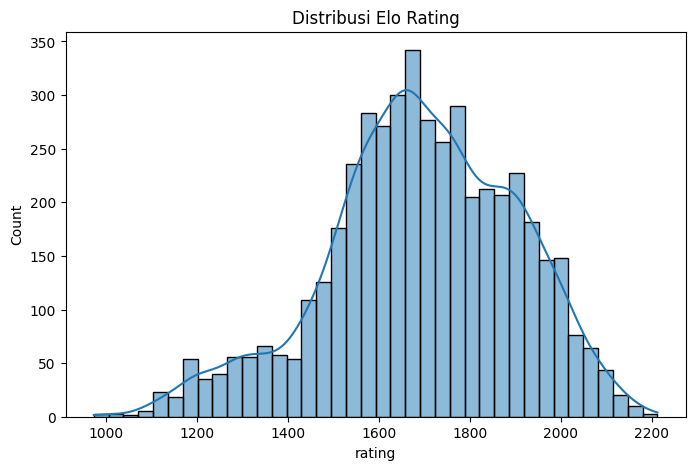

In [77]:
plt.figure(figsize=(8,5))

sns.histplot(
    elo['rating'],
    kde=True
)

plt.title('Distribusi Elo Rating')

plt.show()

In [78]:
elo.sort_values(
    by='rating',
    ascending=False
).head(10)

,year,snapshot_date,country,rank,country_code,rating,rank_max,rating_max,rank_avg,rating_avg,...,matches_home,matches_away,matches_neutral,wins,losses,draws,goals_for,goals_against,confederation,is_host
100,1912,1912-12-31,England,1,EN,2213,1,2213,2,2007,...,69,78,3,106,20,24,598,162,UEFA,0
61,1909,1909-12-31,England,1,EN,2207,1,2207,2,1994,...,60,62,0,85,18,19,505,138,UEFA,0
1611,1962,1962-12-31,Brazil,1,BR,2195,1,2195,6,1939,...,79,67,87,141,55,37,570,308,CONMEBOL,0
3195,1997,1997-12-31,Brazil,1,BR,2179,1,2195,5,1978,...,263,211,184,411,110,137,1446,658,CONMEBOL,0
1963,1970,1970-12-31,Brazil,1,BR,2178,1,2195,6,1946,...,123,104,102,203,73,53,793,421,CONMEBOL,0
4491,2024,2024-12-31,Spain,1,ES,2178,1,2178,7,1943,...,334,298,136,454,138,176,1555,684,UEFA,0
113,1913,1913-12-31,England,1,EN,2174,1,2213,2,2011,...,72,82,3,111,22,24,614,171,UEFA,0
4539,2025,2025-12-31,Spain,1,ES,2172,1,2189,7,1945,...,338,302,138,460,138,180,1588,697,UEFA,0
4635,2026,2026-05-27,Spain,1,ES,2165,1,2189,7,1946,...,340,302,138,461,138,181,1591,697,UEFA,0
4587,2026,2026-12-31,Spain,1,ES,2165,1,2189,7,1946,...,340,302,138,461,138,181,1591,697,UEFA,0


In [79]:
ranking.sort_values(
    by='rank'
).head(10)

,team,team_code,association,rank,previous_rank,points,previous_points,rated_matches
0,Argentina,ARG,CONMEBOL,1,3,1876.118331,1874.814835,59
1,Spain,ESP,UEFA,2,2,1873.013187,1876.395199,56
2,France,FRA,UEFA,3,1,1869.428449,1877.322731,57
3,England,ENG,UEFA,4,4,1827.048678,1825.965482,57
4,Portugal,POR,UEFA,5,5,1766.177547,1763.834406,56
5,Brazil,BRA,CONMEBOL,6,6,1765.856297,1761.160930,55
6,Morocco,MAR,CAF,7,8,1755.100232,1755.868410,87
7,Netherlands,NED,UEFA,8,7,1751.097835,1757.874428,56
8,Belgium,BEL,UEFA,9,9,1742.235945,1734.714832,54
9,Germany,GER,UEFA,10,10,1735.771984,1730.371360,55


### Insight EDA

Negara-negara dengan Elo Rating dan FIFA Ranking terbaik umumnya merupakan kandidat kuat dalam kompetisi internasional.

Hal ini menunjukkan bahwa kedua variabel tersebut berpotensi menjadi fitur penting dalam proses prediksi.

# 3. Data Preparation

In [80]:
print(wc.columns)
print(ranking.columns)
print(elo.columns)

Index(['Year', 'Country', 'Winner', 'Runners-Up', 'Third', 'Fourth',
       'GoalsScored', 'QualifiedTeams', 'MatchesPlayed', 'Attendance'],
      dtype='object')
Index(['team', 'team_code', 'association', 'rank', 'previous_rank', 'points',
       'previous_points', 'rated_matches'],
      dtype='object')
Index(['year', 'snapshot_date', 'country', 'rank', 'country_code', 'rating',
       'rank_max', 'rating_max', 'rank_avg', 'rating_avg', 'rank_min',
       'rating_min', 'matches_total', 'matches_home', 'matches_away',
       'matches_neutral', 'wins', 'losses', 'draws', 'goals_for',
       'goals_against', 'confederation', 'is_host'],
      dtype='object')


## Data Cleaning

Tahap ini dilakukan untuk menyamakan penamaan negara sehingga tidak terjadi duplikasi identitas negara yang sama.

In [81]:
elo['country'] = elo['country'].replace({
    'Germany FR':'Germany',
    'West Germany':'Germany'
})

## Pembuatan Target

Target dibuat berdasarkan data juara dunia historis.

- Juara Dunia = 1
- Bukan Juara Dunia = 0

In [83]:
champions = wc[['Year','Winner']]
elo['target'] = 0
for _, row in champions.iterrows():

    elo.loc[
        (elo['year']==row['Year']) &
        (elo['country']==row['Winner']),
        'target'
    ] = 1

In [84]:
elo['target'].value_counts()

,count
target,
0,4670
1,13


## Feature Selection

Fitur yang digunakan:

- rank
- rating
- wins
- draws
- losses
- goals_for
- goals_against

Target:

- target

In [85]:
features = [
    'rank',
    'rating',
    'wins',
    'draws',
    'losses',
    'goals_for',
    'goals_against'
]

target = 'target'

## Train Test Split

Dataset dibagi menjadi data latih dan data uji dengan proporsi 80:20.

In [86]:
X = elo[features]

y = elo[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Feature Scaling

Standarisasi dilakukan menggunakan StandardScaler agar seluruh fitur memiliki skala yang seragam.

In [87]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# 4. Modeling

## Random Forest Classifier

Random Forest dipilih karena mampu menangani hubungan non-linear antar fitur serta memiliki kemampuan generalisasi yang baik.

In [90]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

# 5. Evaluation

## Accuracy Evaluation

Model dievaluasi menggunakan data testing untuk mengukur kemampuan prediksi terhadap data yang belum pernah dilihat sebelumnya.

In [94]:
pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(
    y_test,
    pred_rf
)

In [102]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    pred_rf
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       934
           1       0.00      0.00      0.00         3

    accuracy                           1.00       937
   macro avg       0.50      0.50      0.50       937
weighted avg       0.99      1.00      1.00       937



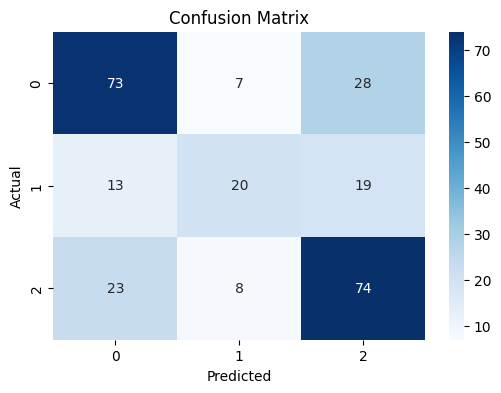

In [103]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Interpretasi:

Nilai accuracy menunjukkan tingkat keberhasilan model dalam melakukan klasifikasi antara negara juara dan bukan juara.

## Feature Importance

Feature Importance digunakan untuk mengetahui fitur yang paling berpengaruh terhadap keputusan model.

In [95]:
importance = pd.DataFrame({
    'Feature':features,
    'Importance':rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
1,rating,0.191883
2,wins,0.160596
6,goals_against,0.150436
3,draws,0.144585
5,goals_for,0.141118
4,losses,0.135372
0,rank,0.076010


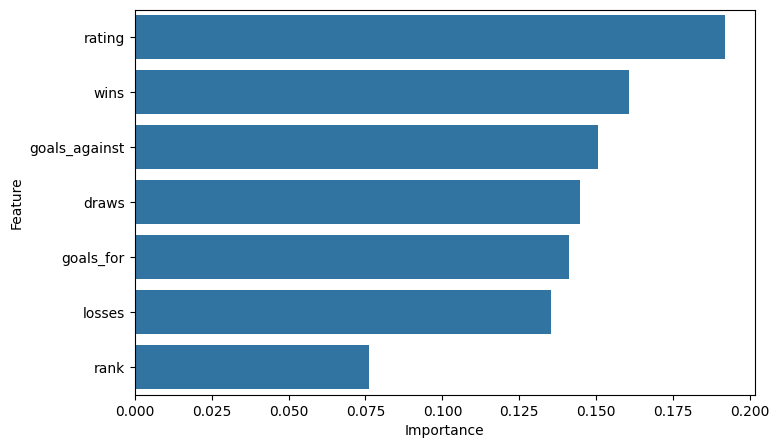

In [96]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.show()

### Interpretasi Feature Importance

Fitur dengan nilai importance tertinggi memiliki pengaruh terbesar terhadap peluang suatu negara menjadi juara dunia.

FIFA Ranking dan Elo Rating diperkirakan menjadi faktor dominan dalam prediksi.

# 6. Prediksi FIFA World Cup 2026

In [97]:
wc2026 = elo[
    elo['year']==2026
]

In [98]:
wc2026['probability'] = rf.predict_proba(
    scaler.transform(
        wc2026[features]
    )
)[:,1]

## Hasil Prediksi

Tabel berikut menunjukkan negara-negara dengan probabilitas tertinggi untuk menjadi juara FIFA World Cup 2026 berdasarkan model Random Forest yang telah dibangun.

In [99]:
prediksi = wc2026[
    ['country','probability']
]

prediksi = prediksi.sort_values(
    by='probability',
    ascending=False
)

prediksi.head(10)

,country,probability
4587,Spain,0.02
4635,Spain,0.02
4589,France,0.00
4588,Argentina,0.00
4591,Brazil,0.00
4592,Portugal,0.00
4593,Colombia,0.00
4590,England,0.00
4595,Ecuador,0.00
4596,Croatia,0.00


In [106]:
prediksi.to_csv(
    "hasil_prediksi_wc2026.csv",
    index=False
)
prediksi.head(10)

,country,probability
4587,Spain,0.02
4635,Spain,0.02
4589,France,0.00
4588,Argentina,0.00
4591,Brazil,0.00
4592,Portugal,0.00
4593,Colombia,0.00
4590,England,0.00
4595,Ecuador,0.00
4596,Croatia,0.00


# 7. Deployment Preparation

Model disimpan dalam format .pkl agar dapat digunakan kembali pada aplikasi deployment seperti Streamlit.

In [100]:
import pickle

pickle.dump(
    rf,
    open('model.pkl','wb')
)

# 8. Conclusion

Berdasarkan hasil pemodelan menggunakan Random Forest Classifier, model berhasil digunakan untuk memprediksi peluang suatu negara menjadi juara FIFA World Cup.

Fitur yang paling berpengaruh terhadap prediksi adalah Elo Rating, FIFA Ranking, dan statistik performa pertandingan.

Model kemudian digunakan untuk menghasilkan prediksi kandidat juara FIFA World Cup 2026 berdasarkan data terbaru yang tersedia.